# Theory

Histogram equalization is a technique used to enhance the contrast of grayscale images by redistributing the intensity values. The goal is to obtain a uniform histogram where all intensity levels are equally probable. This is achieved by applying a transformation function based on the cumulative distribution function (CDF) of the image's histogram.

Given an input image with intensity levels $r$ and its probability distribution $p_r(r)$, the transformation function is:

$$
s = T(r) = (L-1) \int_0^r p_r(w) \, dw
$$

where $L$ is the number of possible intensity levels (typically 256 for 8-bit images).



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def histogram_equalization(input_image):
  # resizing image
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)
  # convert our image into a numpy array
  img = np.asarray(img)

  # put pixels in a 1D array by flattening out img array
  flat = img.flatten()

  # show the histogram
  #plt.hist(flat, bins=256)

  histogram = np.zeros(256)
  # loop through pixels and sum up counts of pixels
  for pixel in flat:
    histogram[pixel] += 1

  #plt.plot(histogram)

  a = iter(histogram)
  b = [next(a)]
  for i in a:
    b.append(b[-1] + i)

  cs = np.array(b)

  # numerator & denomenator
  nj = (cs - cs.min()) * 255
  N = cs.max() - cs.min()

  # re-normalize the cumsum
  cs = nj / N

  # cast it back to uint8 since we can't use floating point values in images
  cs = cs.astype('uint8')


  # get the value from cumulative sum for every index in flat, and set that as img_new
  img_new = cs[flat]
  

  # put array back into original shape since we flattened it
  img_new = np.reshape(img_new, img.shape)

  # set up side-by-side image display
  fig = plt.figure()
  fig.set_figheight(15)
  fig.set_figwidth(15)

  fig.add_subplot(2,2,1)
  plt.imshow(img, cmap='gray')

  #histogram of initial image
  fig.add_subplot(2,2,2)
  plt.hist(flat, bins=50)

  # display the new image
  fig.add_subplot(2,2,3)
  plt.imshow(img_new, cmap='gray')

  #histogram of final image
  fig.add_subplot(2,2,4)
  plt.hist(cs, bins=50)

  plt.show(block=True)

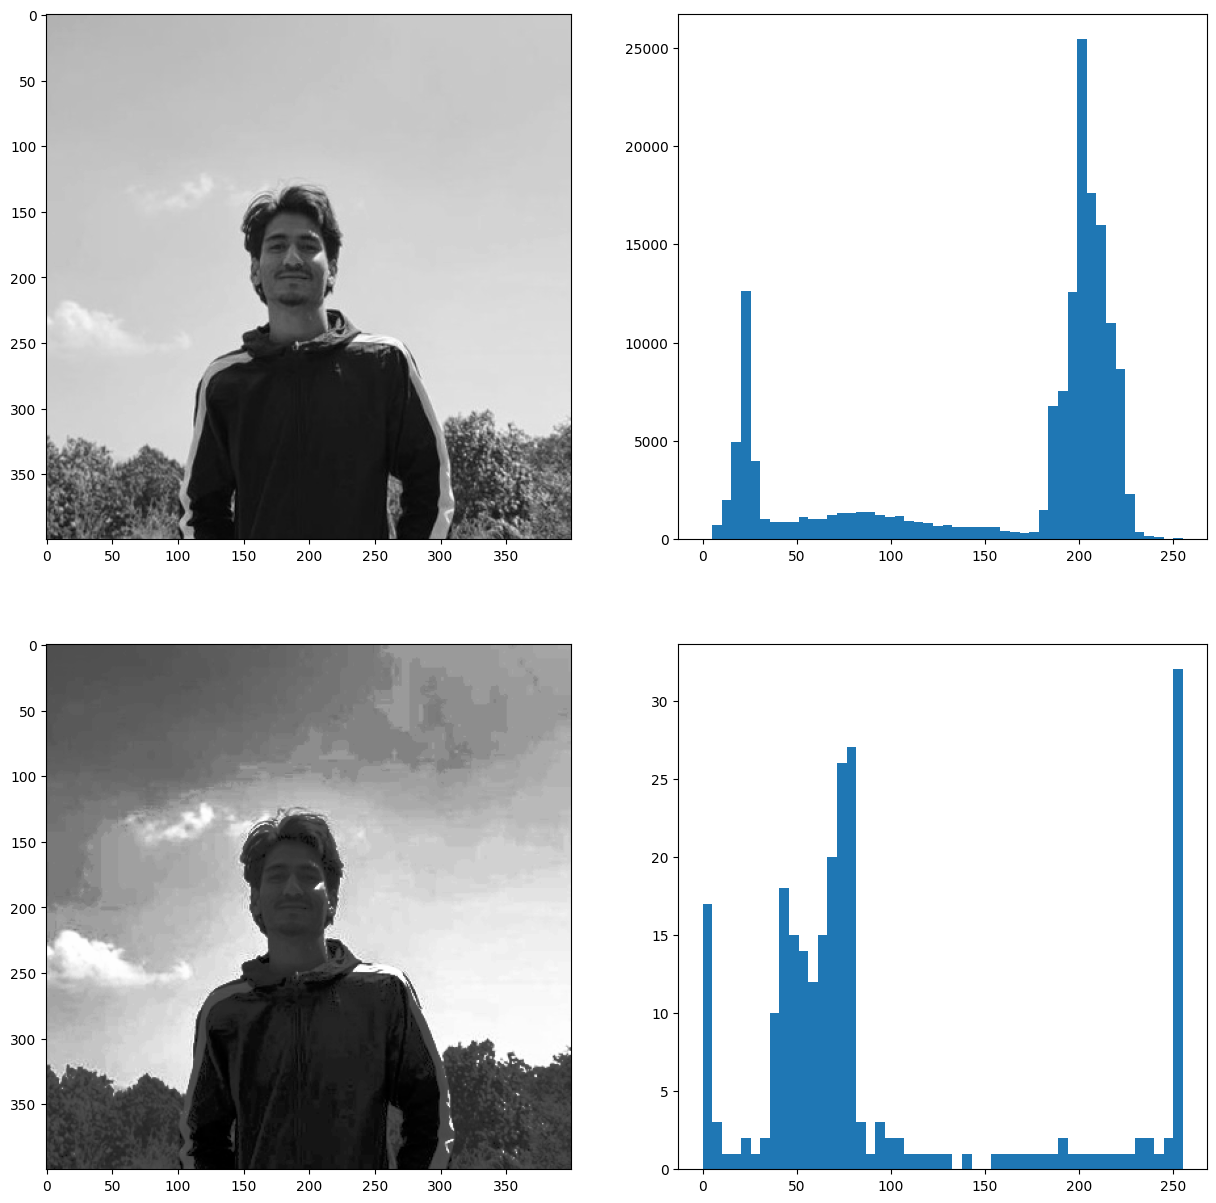

In [3]:
# reading image and converting to gray scale
img = Image.open('img/prakash.jpg').convert('L')
#Calling the histogram equalization function
histogram_equalization(img)

# Conclusion

By applying histogram equalization, the image's contrast is improved, making features more distinguishable. The original image may have a narrow range of intensity values, resulting in poor contrast. After equalization, the intensity values are spread more evenly, as seen in the output image and its histogram. This process is especially useful for enhancing details in images with backgrounds and foregrounds that are both bright or both dark.